#### Loading the Libraries

In [11]:
import pandas as pd
import numpy as np

from joblib import load

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### Loading the Test Dataset

In [12]:
test_data = pd.read_csv(
    '../data/processed/test_data.csv'
)

test_data.shape

(2441, 23)

In [13]:
X_test = test_data.drop(
    'Revenue',
    axis=1
)

y_test = test_data['Revenue']

#### Loading the Saved Models

In [14]:
logistic_pipeline = load(
    '../models/logistic_regression_pipeline.joblib'
)

ridge_pipeline = load(
    '../models/ridge_classifier_pipeline.joblib'
)

decision_tree_pipeline = load(
    '../models/decision_tree_classifier_pipeline.joblib'
)

random_forest_pipeline = load(
    '../models/random_forest_classifier_pipeline.joblib'
)

tuned_random_forest_pipeline = load(
    '../models/tuned_random_forest_classifier_pipeline.joblib'
)

extra_trees_pipeline = load(
    '../models/extra_trees_classifier_pipeline.joblib'
)

tuned_extra_trees_pipeline = load(
    '../models/tuned_extra_trees_classifier_pipeline.joblib'
)

gradient_boosting_pipeline = load(
    '../models/gradient_boosting_classifier_pipeline.joblib'
)

tuned_gradient_boosting_pipeline = load(
    '../models/tuned_gradient_boosting_classifier_pipeline.joblib'
)

hist_gradient_boosting_pipeline = load(
    '../models/hist_gradient_boosting_classifier_pipeline.joblib'
)

tuned_hist_gradient_boosting_pipeline = load(
    '../models/tuned_hist_gradient_boosting_classifier_pipeline.joblib'
)

xgboost_pipeline = load(
    '../models/xgboost_classifier_pipeline.joblib'
)

tuned_xgboost_pipeline = load(
    '../models/tuned_xgboost_classifier_pipeline.joblib'
)

voting_pipeline = load(
    '../models/voting_classifier_pipeline.joblib'
)

stacking_pipeline = load(
    '../models/stacking_classifier_pipeline.joblib'
)

#### Generating Test Predictions

In [15]:
models = {
    'Logistic Regression': logistic_pipeline,
    'Ridge Classifier': ridge_pipeline,
    'Decision Tree': decision_tree_pipeline,
    'Random Forest': random_forest_pipeline,
    'Tuned Random Forest': tuned_random_forest_pipeline,
    'Extra Trees': extra_trees_pipeline,
    'Tuned Extra Trees': tuned_extra_trees_pipeline,
    'Gradient Boosting': gradient_boosting_pipeline,
    'Tuned Gradient Boosting': tuned_gradient_boosting_pipeline,
    'HistGradientBoosting': hist_gradient_boosting_pipeline,
    'Tuned HistGradientBoosting': tuned_hist_gradient_boosting_pipeline,
    'XGBoost': xgboost_pipeline,
    'Tuned XGBoost': tuned_xgboost_pipeline,
    'Voting Classifier': voting_pipeline,
    'Stacking Classifier': stacking_pipeline
}

In [16]:
for name, model in models.items():
    try:
        model.predict(X_test)
        print(f"{name}: fitted")
    except Exception as e:
        print(f"{name}: NOT FITTED")

Logistic Regression: fitted
Ridge Classifier: fitted
Decision Tree: fitted
Random Forest: fitted
Tuned Random Forest: fitted
Extra Trees: fitted
Tuned Extra Trees: fitted
Gradient Boosting: fitted
Tuned Gradient Boosting: fitted
HistGradientBoosting: fitted
Tuned HistGradientBoosting: fitted
XGBoost: fitted
Tuned XGBoost: fitted
Voting Classifier: fitted
Stacking Classifier: fitted


In [17]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

print("Test predictions generated for all models.")

Test predictions generated for all models.


In [18]:
for name, prediction in predictions.items():
    print(
        f"{name}: {len(prediction)} predictions"
    )

Logistic Regression: 2441 predictions
Ridge Classifier: 2441 predictions
Decision Tree: 2441 predictions
Random Forest: 2441 predictions
Tuned Random Forest: 2441 predictions
Extra Trees: 2441 predictions
Tuned Extra Trees: 2441 predictions
Gradient Boosting: 2441 predictions
Tuned Gradient Boosting: 2441 predictions
HistGradientBoosting: 2441 predictions
Tuned HistGradientBoosting: 2441 predictions
XGBoost: 2441 predictions
Tuned XGBoost: 2441 predictions
Voting Classifier: 2441 predictions
Stacking Classifier: 2441 predictions


#### Calculating Evaluation Metrics

In [19]:
evaluation_results = []

for name, model in models.items():

    y_pred = predictions[name]

    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy_score(
            y_test,
            y_pred
        ),
        'Precision': precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

evaluation_results = pd.DataFrame(
    evaluation_results
)

evaluation_results.sort_values(
    'F1-Score',
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.898402,0.655814,0.738220,0.694581
1,Tuned Gradient Boosting,0.893486,0.632609,0.761780,0.691211
2,Tuned XGBoost,0.894306,0.639013,0.746073,0.688406
3,Tuned Random Forest,0.897583,0.659420,0.714660,0.685930
4,Tuned HistGradientBoosting,0.891438,0.630290,0.740838,0.681107
5,Voting Classifier,0.890619,0.627494,0.740838,0.679472
6,Random Forest,0.900860,0.688172,0.670157,0.679045
7,Stacking Classifier,0.896354,0.661654,0.691099,0.676056
8,HistGradientBoosting,0.895944,0.664103,0.678010,0.670984
9,XGBoost,0.894306,0.666667,0.649215,0.657825


#### Important

We're intentionally using F1-score as the primary ranking metric because the Revenue=True class is substantially smaller than Revenue=False.

But we're keeping Accuracy, Precision, and Recall visible so we can understand the trade-offs rather than blindly selecting the highest F1.

#### observations:

- Gradient Boosting beats its tuned version on F1: 0.6946 vs 0.6912.
- Tuned Gradient Boosting has the highest recall at 0.7618, meaning it catches the most purchasing sessions, but at the cost of precision.
- Random Forest has the highest accuracy at 0.9009, but its F1 is lower than Gradient Boosting.
- The ensemble models didn't outperform the best individual boosting models.
- Extra Trees is clearly weaker on this test set, especially recall.

So far, Gradient Boosting is our leading candidate, but we're not selecting it yet.

#### Calculating ROC-AUC Scores

In [20]:
roc_auc_results = []

for name, model in models.items():

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    roc_auc_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(
            y_test,
            y_score
        )
    })

roc_auc_results = pd.DataFrame(
    roc_auc_results
)

roc_auc_results.sort_values(
    'ROC-AUC',
    ascending=False
).reset_index(drop=True)

,Model,ROC-AUC
0,Tuned HistGradientBoosting,0.936369
1,Tuned XGBoost,0.935302
2,Tuned Gradient Boosting,0.932349
3,Gradient Boosting,0.931974
4,Voting Classifier,0.931487
5,HistGradientBoosting,0.931304
6,Tuned Random Forest,0.926278
7,XGBoost,0.925086
8,Random Forest,0.920738
9,Stacking Classifier,0.920083


#### Comparing Evaluation Metrics

In [21]:
evaluation_summary = (
    evaluation_results
    .merge(
        roc_auc_results,
        on='Model'
    )
    .sort_values(
        'F1-Score',
        ascending=False
    )
    .reset_index(drop=True)
)

evaluation_summary

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.898402,0.655814,0.738220,0.694581,0.931974
1,Tuned Gradient Boosting,0.893486,0.632609,0.761780,0.691211,0.932349
2,Tuned XGBoost,0.894306,0.639013,0.746073,0.688406,0.935302
3,Tuned Random Forest,0.897583,0.659420,0.714660,0.685930,0.926278
4,Tuned HistGradientBoosting,0.891438,0.630290,0.740838,0.681107,0.936369
5,Voting Classifier,0.890619,0.627494,0.740838,0.679472,0.931487
6,Random Forest,0.900860,0.688172,0.670157,0.679045,0.920738
7,Stacking Classifier,0.896354,0.661654,0.691099,0.676056,0.920083
8,HistGradientBoosting,0.895944,0.664103,0.678010,0.670984,0.931304
9,XGBoost,0.894306,0.666667,0.649215,0.657825,0.925086


In [22]:
evaluation_summary_plot = (
    evaluation_summary
    .sort_values(
        'F1-Score',
        ascending=True
    )
)

evaluation_summary_plot[
    ['Model', 'F1-Score', 'ROC-AUC']
]

,Model,F1-Score,ROC-AUC
14,Extra Trees,0.525316,0.895214
13,Ridge Classifier,0.527256,0.858651
12,Decision Tree,0.565432,0.751414
11,Tuned Extra Trees,0.567455,0.892921
10,Logistic Regression,0.617108,0.908208
9,XGBoost,0.657825,0.925086
8,HistGradientBoosting,0.670984,0.931304
7,Stacking Classifier,0.676056,0.920083
6,Random Forest,0.679045,0.920738
5,Voting Classifier,0.679472,0.931487


#### Generating Confusion Matrices

In [23]:
top_models = (
    evaluation_summary
    .head(5)['Model']
    .tolist()
)

top_models

['Gradient Boosting',
 'Tuned Gradient Boosting',
 'Tuned XGBoost',
 'Tuned Random Forest',
 'Tuned HistGradientBoosting']

In [24]:
confusion_matrices = {}

for name in top_models:

    confusion_matrices[name] = confusion_matrix(
        y_test,
        predictions[name]
    )

confusion_matrices

{'Gradient Boosting': array([[1911,  148],
        [ 100,  282]]),
 'Tuned Gradient Boosting': array([[1890,  169],
        [  91,  291]]),
 'Tuned XGBoost': array([[1898,  161],
        [  97,  285]]),
 'Tuned Random Forest': array([[1918,  141],
        [ 109,  273]]),
 'Tuned HistGradientBoosting': array([[1893,  166],
        [  99,  283]])}

The important business trade-off is:

- Gradient Boosting has the best F1, with a balanced 148 FP / 100 FN profile.
- Tuned Gradient Boosting catches the most actual purchasers (291 TP) and has the fewest missed purchasers (91 FN), but generates more false positives (169 FP).
- Tuned Random Forest is the most conservative of these five, with only 141 FP, but misses more purchasers (109 FN).

So there isn't a single universally "best" model — it depends on whether missing a potential purchaser or unnecessarily targeting a non-purchaser is more costly.

But for this project, F1 currently gives Gradient Boosting the strongest overall balance.

#### Reviewing Classification Reports

In [25]:
for name in top_models:

    print(
        f"\n{name}"
    )

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=[
                'No Purchase',
                'Purchase'
            ],
            zero_division=0
        )
    )


Gradient Boosting
              precision    recall  f1-score   support

 No Purchase       0.95      0.93      0.94      2059
    Purchase       0.66      0.74      0.69       382

    accuracy                           0.90      2441
   macro avg       0.80      0.83      0.82      2441
weighted avg       0.90      0.90      0.90      2441


Tuned Gradient Boosting
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.94      2059
    Purchase       0.63      0.76      0.69       382

    accuracy                           0.89      2441
   macro avg       0.79      0.84      0.81      2441
weighted avg       0.90      0.89      0.90      2441


Tuned XGBoost
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.94      2059
    Purchase       0.64      0.75      0.69       382

    accuracy                           0.89      2441
   macro avg       0.80      0.83      0.81      2441
weighted avg   

The differences are small, but they tell an important story:

- Gradient Boosting provides the strongest overall balance.
- Tuned Gradient Boosting sacrifices precision for higher recall.
- Tuned XGBoost behaves similarly, with slightly lower precision than the original Gradient Boosting.
- Tuned Random Forest has the same precision as Gradient Boosting but lower recall.
- Tuned HistGradientBoosting falls slightly behind on F1.

And importantly, Gradient Boosting's ROC-AUC of 0.9320 is still excellent, even though the tuned HistGradientBoosting and tuned XGBoost rank higher on ROC-AUC.

So our conclusion is not simply:

"Gradient Boosting has the highest score."

It's:

Gradient Boosting provides the best overall balance between identifying purchasing sessions and limiting incorrect purchase predictions at the selected classification threshold.

#### Comparing ROC Curves

In [26]:
from sklearn.metrics import roc_curve

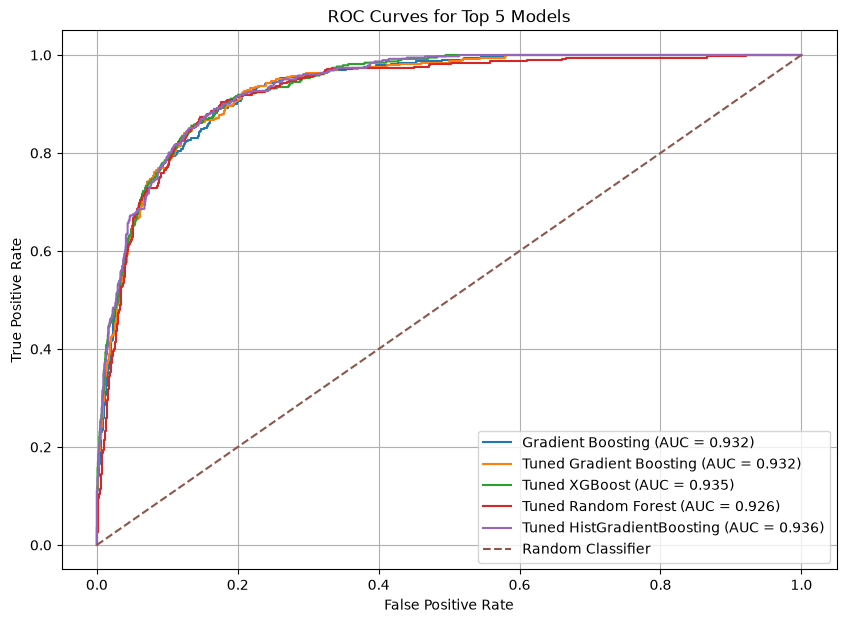

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for name in top_models:

    model = models[name]

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    auc_score = roc_auc_score(
        y_test,
        y_score
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc_score:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Top 5 Models')
plt.legend()
plt.grid(True)
plt.show()

#### Comparing Precision–Recall Curves

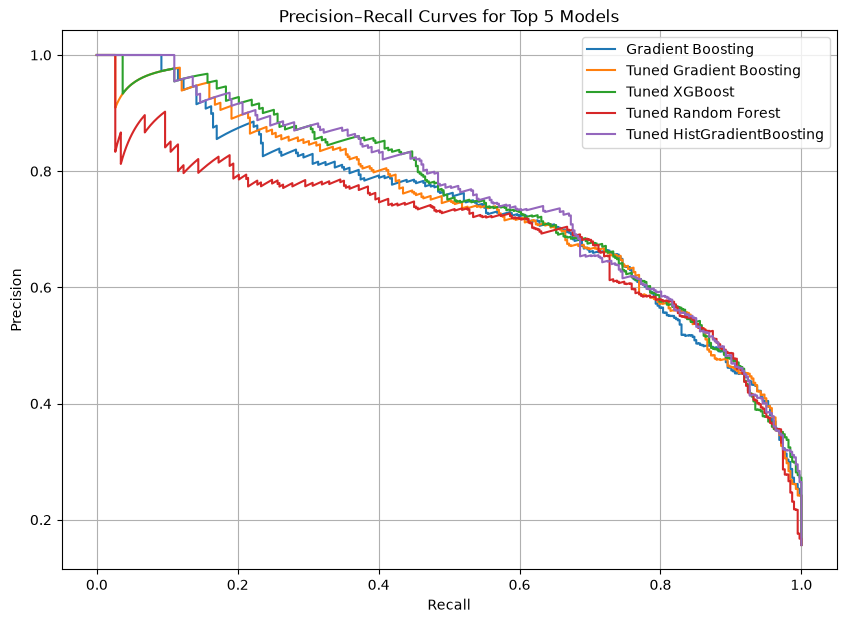

In [28]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

for name in top_models:

    model = models[name]

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]

    else:
        y_score = model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_score
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curves for Top 5 Models')
plt.legend()
plt.grid(True)
plt.show()

#### Analyzing Classification Thresholds

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

final_candidate = models[
    'Gradient Boosting'
]

y_score = final_candidate.predict_proba(
    X_test
)[:, 1]

for threshold in thresholds:

    y_pred_threshold = (
        y_score >= threshold
    ).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        'F1-Score': f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Precision,Recall,F1-Score
0,0.10,0.386653,0.955497,0.550528
1,0.15,0.443467,0.924084,0.599321
2,0.20,0.480282,0.892670,0.624542
3,0.25,0.515974,0.845550,0.640873
4,0.30,0.551786,0.808901,0.656051
5,0.35,0.581888,0.790576,0.670366
6,0.40,0.605317,0.774869,0.679679
7,0.45,0.625000,0.759162,0.685579
8,0.50,0.655814,0.738220,0.694581
9,0.55,0.662651,0.719895,0.690088


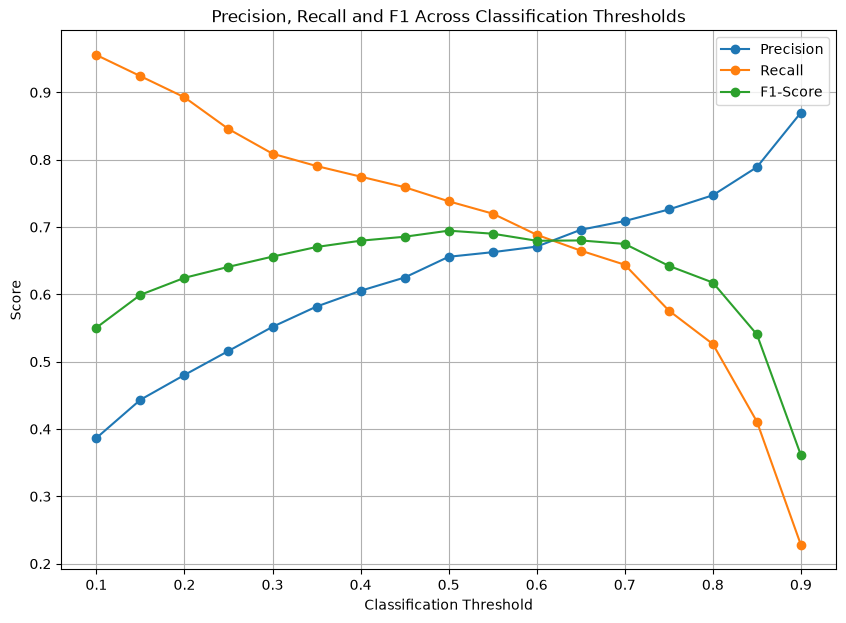

In [30]:
plt.figure(figsize=(10, 7))

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results['Threshold'],
    threshold_results['F1-Score'],
    marker='o',
    label='F1-Score'
)

plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 Across Classification Thresholds')
plt.legend()
plt.grid(True)
plt.show()

for Gradient Boosting, the default 0.50 threshold is already the best among the thresholds we tested.

At 0.50:

- Precision = 0.656
- Recall = 0.738
- F1 = 0.695

At 0.55, precision improves slightly to 0.663, but recall drops enough that F1 falls to 0.690.

At 0.65, precision reaches 0.696, but recall drops to 0.665, so F1 is only 0.680.

This is a good finding

It means we don't need to introduce a custom threshold just for the sake of optimization.

Our conclusion can eventually be:

The default 0.50 classification threshold provides the strongest F1-score among the evaluated thresholds, so no threshold adjustment is required for the final model.

#### Analyzing Final Model Errors

In [31]:
error_analysis = X_test.copy()

error_analysis['Actual'] = y_test.values

error_analysis['Predicted'] = final_candidate.predict(
    X_test
)

error_analysis['Prediction_Probability'] = y_score

error_analysis['Error_Type'] = np.select(
    [
        (error_analysis['Actual'] == True) &
        (error_analysis['Predicted'] == False),

        (error_analysis['Actual'] == False) &
        (error_analysis['Predicted'] == True)
    ],
    [
        'False Negative',
        'False Positive'
    ],
    default='Correct'
)

error_analysis['Error_Type'].value_counts()

Error_Type
Correct           2193
False Positive     148
False Negative     100
Name: count, dtype: int64

#### Analyzing False Negatives

In [32]:
false_negatives = error_analysis[
    error_analysis['Error_Type'] == 'False Negative'
].copy()

false_negatives.shape

(100, 26)

In [33]:
false_negatives.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Total_Pages_Viewed,Total_Browsing_Duration,Product_Page_Share,Avg_Duration_Per_Page,Product_Duration_Share,Prediction_Probability
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,3.940000,163.654064,1.030000,57.826783,55.080000,2209.655731,0.009245,0.027851,4.862544,0.012000,2.140000,2.280000,3.050000,4.460000,60.050000,2431.136578,0.855439,39.123777,0.810323,0.233117
std,4.027231,245.014251,1.635805,125.330353,56.876915,2564.058841,0.023926,0.025835,12.983372,0.074237,1.110283,1.775706,2.438641,4.038752,58.695133,2652.778452,0.171761,23.649738,0.274864,0.127968
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.003452,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.200000,0.000000,0.000000,0.029852
25%,0.000000,0.000000,0.000000,0.000000,15.000000,447.937500,0.000000,0.014201,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,18.500000,594.312500,0.825815,22.612147,0.811199,0.137154
50%,3.000000,72.120000,0.000000,0.000000,35.500000,1413.512500,0.002936,0.022309,0.000000,0.000000,2.000000,2.000000,2.000000,2.000000,40.500000,1613.465000,0.903846,34.982924,0.921462,0.226072
75%,6.000000,200.273810,2.000000,36.562500,77.000000,2669.131250,0.010232,0.032108,1.941416,0.000000,3.000000,2.000000,4.000000,6.000000,84.000000,3236.054762,0.980092,49.712546,0.982720,0.311012
max,18.000000,1559.750000,10.000000,763.000000,309.000000,13430.976060,0.200000,0.200000,84.306638,0.600000,8.000000,12.000000,9.000000,20.000000,319.000000,14373.998389,1.000000,163.340891,1.000000,0.498899


- The model missed purchases even though these sessions had substantial product activity: median 35.5 ProductRelated pages and median 1,413.5 seconds of ProductRelated duration.
- The median PageValues is 0, despite these being actual purchases. So some purchasing sessions don't have a strong PageValues signal for the model.
- The median prediction probability is only 0.226, meaning many of these actual purchasers looked relatively unlikely to purchase to the model.
- The middle 50% of prediction probabilities is roughly 0.137–0.311, so many false negatives sit well below our 0.50 threshold.

#### Analyzing False Positives

In [34]:
false_positives = error_analysis[
    error_analysis['Error_Type'] == 'False Positive'
].copy()

false_positives.shape

(148, 26)

In [35]:
false_positives.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Total_Pages_Viewed,Total_Browsing_Duration,Product_Page_Share,Avg_Duration_Per_Page,Product_Duration_Share,Prediction_Probability
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,4.398649,136.897394,1.054054,70.561768,53.101351,2028.169336,0.007216,0.022580,22.972320,0.029730,2.155405,2.283784,3.270270,3.513514,58.554054,2235.628498,0.890578,40.742369,0.902547,0.757410
std,3.850506,216.669946,2.052985,165.651995,48.380400,1932.833128,0.010906,0.014576,25.368968,0.151841,1.067216,1.722364,2.462217,3.457195,50.549805,2056.838119,0.085758,22.808952,0.110827,0.118561
min,0.000000,0.000000,0.000000,0.000000,6.000000,112.083333,0.000000,0.001042,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,6.000000,130.166667,0.638889,9.264286,0.432615,0.501194
25%,1.000000,26.900000,0.000000,0.000000,23.750000,828.340119,0.000000,0.012199,9.127553,0.000000,2.000000,2.000000,1.000000,2.000000,28.000000,914.364583,0.838335,26.525757,0.874394,0.659003
50%,4.000000,80.700000,0.000000,0.000000,36.000000,1344.375028,0.003573,0.019501,17.425854,0.000000,2.000000,2.000000,3.000000,2.000000,42.000000,1541.941666,0.902574,34.552421,0.936911,0.781143
75%,6.000000,154.500000,1.000000,41.500000,66.000000,2627.246755,0.008733,0.030809,27.918186,0.000000,2.000000,2.000000,4.000000,4.000000,70.000000,2815.116038,0.956753,48.522304,0.977643,0.862053
max,21.000000,1449.666667,14.000000,1021.600000,287.000000,12983.787710,0.056667,0.090476,246.758590,1.000000,8.000000,13.000000,9.000000,20.000000,304.000000,13621.594879,1.000000,145.839149,1.000000,0.934497


The most important difference is prediction confidence:

- False negatives had a median probability of only 0.226, even though they actually purchased.
- False positives had a median probability of 0.781, even though they didn't purchase.

So the model is making two different kinds of mistakes:

- False negatives:
The model often sees these sessions as relatively low-probability purchase sessions, despite substantial browsing/product activity.

- False positives:
The model is quite confident that these sessions will purchase, suggesting that some non-purchasing sessions exhibit behavioral patterns very similar to actual purchasers.

That's a much more meaningful evaluation finding than simply saying "the model made 248 errors.

#### Comparing Model Error Profiles

In [36]:
error_profile = pd.DataFrame({
    'Metric': [
        'Administrative',
        'Informational',
        'ProductRelated',
        'ProductRelated_Duration',
        'BounceRates',
        'ExitRates',
        'PageValues',
        'Total_Pages_Viewed',
        'Total_Browsing_Duration',
        'Product_Page_Share',
        'Avg_Duration_Per_Page',
        'Product_Duration_Share',
        'Prediction_Probability'
    ],
    'False Negative Median': [
        false_negatives[column].median()
        for column in [
            'Administrative',
            'Informational',
            'ProductRelated',
            'ProductRelated_Duration',
            'BounceRates',
            'ExitRates',
            'PageValues',
            'Total_Pages_Viewed',
            'Total_Browsing_Duration',
            'Product_Page_Share',
            'Avg_Duration_Per_Page',
            'Product_Duration_Share',
            'Prediction_Probability'
        ]
    ],
    'False Positive Median': [
        false_positives[column].median()
        for column in [
            'Administrative',
            'Informational',
            'ProductRelated',
            'ProductRelated_Duration',
            'BounceRates',
            'ExitRates',
            'PageValues',
            'Total_Pages_Viewed',
            'Total_Browsing_Duration',
            'Product_Page_Share',
            'Avg_Duration_Per_Page',
            'Product_Duration_Share',
            'Prediction_Probability'
        ]
    ]
})

error_profile

,Metric,False Negative Median,False Positive Median
0,Administrative,3.000000,4.000000
1,Informational,0.000000,0.000000
2,ProductRelated,35.500000,36.000000
3,ProductRelated_Duration,1413.512500,1344.375028
4,BounceRates,0.002936,0.003573
5,ExitRates,0.022309,0.019501
6,PageValues,0.000000,17.425854
7,Total_Pages_Viewed,40.500000,42.000000
8,Total_Browsing_Duration,1613.465000,1541.941666
9,Product_Page_Share,0.903846,0.902574


The key difference is PageValues + model confidence

The two error groups have remarkably similar browsing behavior:

- ProductRelated: 35.5 vs 36
- Total pages: 40.5 vs 42
- Product duration: 1,413.5 vs 1,344.4
- Product page share: 0.904 vs 0.903

So the model isn't simply struggling because one group browses dramatically more or less.

But:

- False Negatives → PageValues median = 0
- False Positives → PageValues median = 17.43
- False Negatives → prediction probability = 0.226
- False Positives → prediction probability = 0.781

The model tends to miss some genuine purchases when their observed session behavior lacks a strong PageValues signal, while some non-purchasing sessions generate strong purchase-like signals and receive high predicted probabilities.

That's exactly the kind of error-level insight we wanted from evaluation.

And notice something else: the false-positive group is actually more confidently misclassified than the false-negative group. That's important because simply lowering the threshold wouldn't necessarily solve the overall problem, we'd catch more purchases, but we'd also create more false positives.

#### Selecting the Final Model

In [37]:
final_model_name = 'Gradient Boosting'

final_model = models[
    final_model_name
]

final_predictions = predictions[
    final_model_name
]

In [38]:
final_model_name

'Gradient Boosting'

In [39]:
evaluation_summary[
    evaluation_summary['Model'] == final_model_name
]

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.898402,0.655814,0.73822,0.694581,0.931974


#### Saving Evaluation Results

In [40]:
evaluation_summary.to_csv(
    '../data/processed/model_evaluation_results.csv',
    index=False
)

In [41]:
final_predictions_data = X_test.copy()

final_predictions_data['Actual'] = y_test.values

final_predictions_data['Predicted'] = final_predictions

final_predictions_data['Prediction_Probability'] = (
    final_model.predict_proba(X_test)[:, 1]
)

final_predictions_data.to_csv(
    '../data/processed/final_model_predictions.csv',
    index=False
)

In [42]:
threshold_results.to_csv(
    '../data/processed/threshold_analysis.csv',
    index=False
)

In [43]:
import os

evaluation_files = [
    '../data/processed/model_evaluation_results.csv',
    '../data/processed/final_model_predictions.csv',
    '../data/processed/threshold_analysis.csv'
]

for file in evaluation_files:
    print(
        file,
        '→',
        'Exists' if os.path.exists(file) else 'Missing'
    )

../data/processed/model_evaluation_results.csv → Exists
../data/processed/final_model_predictions.csv → Exists
../data/processed/threshold_analysis.csv → Exists


Model Performance

Gradient Boosting provides the strongest balance between identifying purchases and limiting incorrect purchase predictions.

Key Observations:
- Gradient Boosting achieves the highest test-set F1-score of 0.6946, with 73.8% recall and 65.6% precision for purchase sessions.
- Tuned Gradient Boosting achieves slightly higher recall at 76.2%, but its F1-score of 0.6912 remains below the standard Gradient Boosting model.

Business Insights:
- Use Gradient Boosting as the primary model when both missed purchases and incorrect purchase predictions need to be balanced.
- Retain tuned Gradient Boosting as an alternative when identifying a larger share of potential purchasers is more important than maintaining the best overall F1-score.

ROC-AUC Performance

Tuned HistGradientBoosting provides the strongest overall ranking ability despite not achieving the highest purchase-class F1-score.

Key Observations:
- Tuned HistGradientBoosting records the highest ROC-AUC of 0.9364, followed by Tuned XGBoost at 0.9353.
- Gradient Boosting records a strong ROC-AUC of 0.9320, while achieving the highest test-set F1-score.

Business Insights:
- Use ROC-AUC alongside F1-score when comparing models because ranking performance and classification performance can favor different models.
- Retain Tuned HistGradientBoosting and Tuned XGBoost as strong candidates for future model refinement or probability-based decision systems.

Precision–Recall Performance

The strongest models maintain a useful trade-off between purchase detection and prediction precision.

Key Observations:
- Gradient Boosting and the tuned boosting models maintain substantially stronger purchase-class performance than Logistic Regression, Ridge Classifier, and the tree-only baseline models.
- The precision–recall curves show that stronger models maintain higher precision across a broader range of recall values.

Business Insights:
- Prioritize boosting-based models when the objective is to identify purchase sessions while controlling false purchase predictions.
- Use precision–recall analysis when selecting operating points for campaigns where the cost of missed and incorrectly targeted customers differs.

Classification Threshold

The default 0.50 classification threshold provides the best F1-score for the selected Gradient Boosting model.

Key Observations:
- The 0.50 threshold produces the highest tested F1-score of 0.6946.
- Lower thresholds increase recall but reduce precision, while higher thresholds increase precision at the expense of recall.

Business Insights:
- Retain the default 0.50 threshold for the current final model because it provides the strongest tested F1 balance.
- Revisit the threshold only when the business cost of false positives versus false negatives changes.


Final Model Errors

The final model identifies most sessions correctly but still misses a meaningful subset of actual purchases.

Key Observations:
- Gradient Boosting correctly classifies 2,193 of 2,441 test sessions, with 148 false positives and 100 false negatives.
- False negatives represent actual purchase sessions that the model assigns below the purchase classification threshold.

Business Insights:
- Monitor false-negative sessions because they represent purchase opportunities that the model fails to identify.
- Use the error patterns as a basis for future feature engineering and model improvement rather than relying only on aggregate accuracy.
